In [1]:
import pandas, numpy

In [2]:
import scipy, scipy.signal

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = 'DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(20196, 15)


,h1M8_1,h1M8_2,h1M8_3,h2F14_1,h2F14_2,h2F14_3,h2M8_1,h2M8_2,h2M8_3,KO_1,KO_2,KO_3,WT_1,WT_2,WT_3
FBgn0000008,7.888992,2.404364,7.641325,4.496739,4.474108,3.101558,4.169942,1.109283,2.990706,1.868627,6.349273,2.046127,3.973536,4.069418,13.169861
FBgn0000014,20.584356,9.116074,16.522137,15.028010,21.370556,14.917465,8.706565,3.393639,9.797755,9.116257,13.886094,7.729379,17.593189,17.433641,26.561830
FBgn0000015,4.750318,2.421290,4.041314,3.888815,5.497831,3.691880,3.295904,1.335717,2.375402,2.341026,4.271938,2.319874,5.166222,4.948848,5.854713
FBgn0000017,18.593702,10.642545,16.094865,12.066664,15.937162,4.499557,9.407700,3.693964,8.149117,6.646698,9.728445,5.603754,13.220405,15.056392,19.031383
FBgn0000018,7.344876,5.077850,5.495519,6.130012,5.916365,5.738847,6.771208,4.022657,6.456481,4.897385,5.102448,3.645305,8.031238,8.084451,6.875136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RR51048_transposable_element,0.000000,0.000000,0.000000,0.000000,0.010833,0.000000,0.000000,0.013156,0.000000,0.017752,0.017819,0.000000,0.109559,0.000000,0.098044
RR51093_transposable_element,0.000000,0.000000,0.378845,0.000000,0.391035,1.290643,0.098497,1.382451,0.222965,0.232897,0.465807,0.000000,0.398241,0.560288,0.201621
RR51475_transposable_element,0.731425,1.404666,2.041584,0.587566,1.355312,17.322956,10.440089,45.617028,5.626746,4.394941,2.425542,2.004484,13.506209,17.595002,7.525028
RR51477_transposable_element,0.009972,0.017888,0.021606,0.021574,0.005813,0.014672,0.098988,0.085491,0.032967,0.009189,0.033684,0.016833,0.042574,0.000000,0.106921


# 3. filter and transform

In [6]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(11396, 15)
(1458, 15)


In [7]:
log_expression = numpy.log2(substantial_expression + 1) # why plus one?
log_expression

,h1M8_1,h1M8_2,h1M8_3,h2F14_1,h2F14_2,h2F14_3,h2M8_1,h2M8_2,h2M8_3,KO_1,KO_2,KO_3,WT_1,WT_2,WT_3
FBgn0000008,3.152020,1.767385,3.111253,2.458576e+00,2.452624,2.036172,2.370148,1.076753,1.996644,1.520361e+00,2.877602e+00,1.606976,2.314272,2.341820e+00,3.824754e+00
FBgn0000014,4.431914,3.338578,4.131107,4.002523e+00,4.483529,3.992539,3.278961,2.135416,3.432659,3.338604e+00,3.895893e+00,3.125879,4.216702,4.204269e+00,4.784600e+00
FBgn0000015,2.523642,1.774540,2.333800,2.289485e+00,2.699958,2.230166,2.102962,1.223866,1.755060,1.740291e+00,2.398333e+00,1.731129,2.624387,2.572610e+00,2.777096e+00
FBgn0000017,4.292318,3.541335,4.095491,3.707819e+00,4.082120,2.459315,3.379579,2.230807,3.193632,2.934837e+00,3.423369e+00,2.723286,3.829891,4.005076e+00,4.324190e+00
FBgn0000018,3.060891,2.603561,2.699445,2.833905e+00,2.790014,2.752502,2.958139,2.328451,2.898495,2.560075e+00,2.609388e+00,2.215773,3.174924,3.183399e+00,2.977305e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RR48348_transposable_element,1.525852,1.776530,2.084070,5.632261e+00,5.928499,4.821940,0.554200,0.008101,0.044212,2.054354e+00,2.928149e+00,1.885360,1.206848,2.280953e+00,1.459097e+00
RR48391_transposable_element,1.038722,1.076630,1.424597,3.429379e-09,0.103947,0.000001,0.662806,1.325603,1.500935,2.307974e-09,2.597541e-09,0.000000,1.107537,1.952288e+00,2.124073e+00
RR48399_transposable_element,0.022713,0.198796,0.170703,1.514366e-03,1.787625,3.013423,1.384712,2.863089,1.462584,2.132135e-02,7.915902e-01,0.041978,0.000000,0.000000e+00,3.114793e-07
RR48532_transposable_element,2.833434,3.056547,3.899365,4.581070e+00,5.213630,6.699344,3.795721,6.286518,4.499345,4.474501e+00,4.409355e+00,3.848164,1.374042,1.646613e-07,3.486968e-03


# 4. visualize substantial expression

15.54006771233757


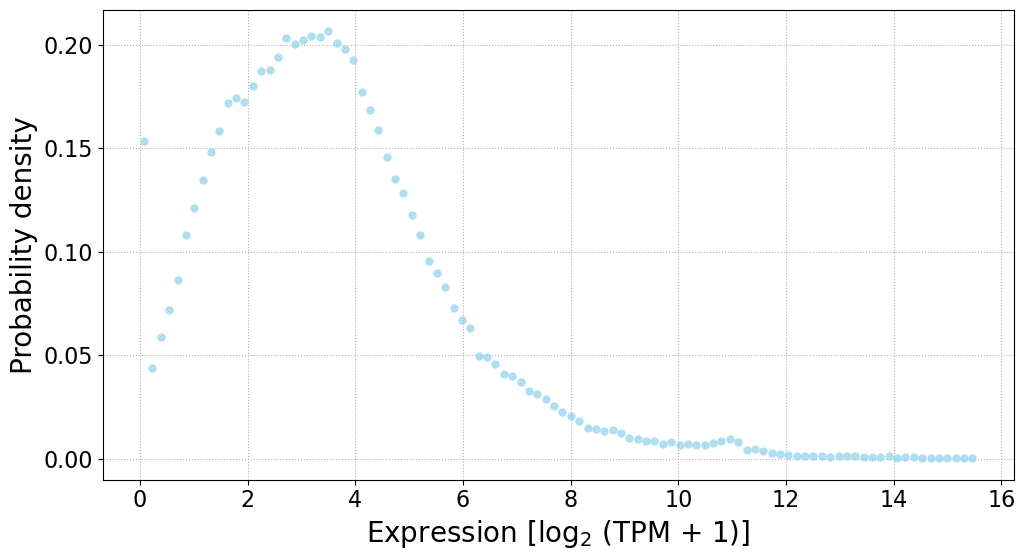

In [8]:
number_of_bins = 100
found_max = numpy.max(log_expression)
print(found_max)

hist, bin_edges = numpy.histogram(log_expression, bins=number_of_bins, range=(0, found_max), density=True)
half_bin = (bin_edges[1] - bin_edges[0])/2
x = bin_edges + half_bin
x = x[:-1]

matplotlib.pyplot.plot(x, hist, 'o', alpha=2/3, mec='none', color='skyblue')

matplotlib.pyplot.xlabel('Expression [log$_2$ (TPM + 1)]')
matplotlib.pyplot.ylabel('Probability density')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

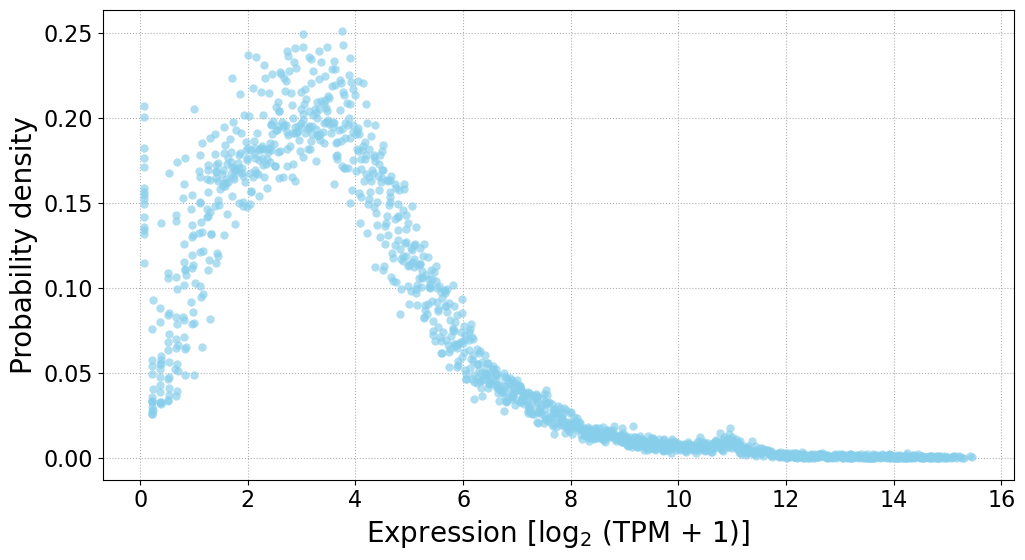

In [9]:
for column in log_expression.columns:
    sample_expression = log_expression[column]
    
    number_of_bins = 100
    found_max = numpy.max(sample_expression)
    
    hist, bin_edges = numpy.histogram(sample_expression, bins=number_of_bins, range=(0, found_max), density=True)
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
    
    matplotlib.pyplot.plot(x, hist, 'o', alpha=2/3, mec='none', color='skyblue')

matplotlib.pyplot.xlabel('Expression [log$_2$ (TPM + 1)]')
matplotlib.pyplot.ylabel('Probability density')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()    

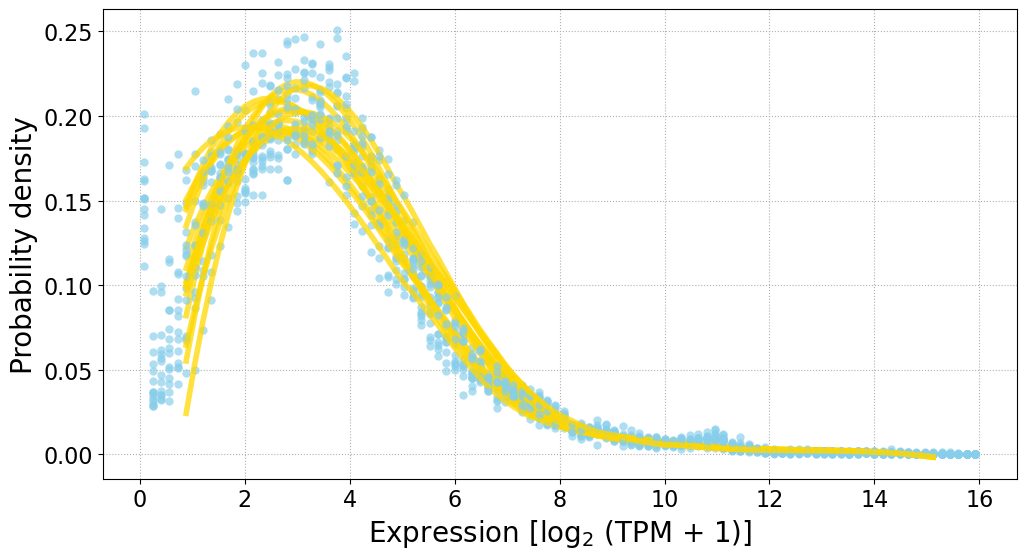

In [10]:
for column in log_expression.columns:
    sample_expression = log_expression[column]
    
    number_of_bins = 100
    found_max = numpy.max(sample_expression)
    found_max = 16
    
    hist, bin_edges = numpy.histogram(sample_expression, bins=number_of_bins, range=(0, found_max), density=True)
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
    
    matplotlib.pyplot.plot(x, hist, 'o', alpha=2/3, mec='none', color='skyblue')
    
    margin = 5
    plotting_x = x[margin:number_of_bins-margin]
    plotting_hist = hist[margin:number_of_bins-margin]
    
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)
    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=4, alpha=3/4, color='gold')

matplotlib.pyplot.xlabel('Expression [log$_2$ (TPM + 1)]')
matplotlib.pyplot.ylabel('Probability density')
matplotlib.pyplot.grid(ls=':')

#matplotlib.pyplot.ylim(-0.05, 0.2)

matplotlib.pyplot.tight_layout()

matplotlib.pyplot.xlabel('Expression [log$_2$ (TPM + 1)]')
matplotlib.pyplot.ylabel('Probability density')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()    